# Feature Analysis
Analyze the processed lap data and feature relationships.

In [4]:
from f1deg.viz.theme import apply_theme

apply_theme()

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_parquet("../data/processed/laps_clean.parquet")
print(f"Loaded {len(df)} laps from {df['race_id'].nunique()} races")
print(f"Compounds: {sorted(df['compound'].unique())}")
print(f"Circuits: {df['circuit_id'].nunique()}")
df.describe()

Loaded 165614 laps from 92 races
Compounds: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']
Circuits: 25


,lap_number,lap_time_seconds,tyre_life,tyre_life_sq,fuel_mass_kg,air_temp,track_temp,humidity,pressure,wind_speed,wind_direction,stint_number,stint_lap
count,165614.000000,165614.000000,165614.000000,165614.000000,165614.000000,85934.000000,85934.000000,85934.000000,85934.000000,85934.000000,85934.000000,165614.000000,165614.000000
mean,30.915587,88.899307,15.262876,337.702429,65.132120,24.050549,35.482552,52.851211,984.957848,1.809646,183.643191,1.836687,81.800144
std,18.281428,10.813084,10.234631,482.001439,27.408706,4.817285,8.949100,17.503882,54.791829,1.094368,98.560786,0.774870,110.989373
min,2.000000,67.012000,1.000000,1.000000,0.000000,12.800000,15.600000,5.000000,778.500000,0.000000,0.000000,1.000000,1.000000
25%,15.000000,80.706000,8.000000,64.000000,44.000000,20.400000,29.400000,40.000000,987.000000,1.100000,115.000000,1.000000,10.000000
50%,30.000000,87.194000,13.000000,169.000000,66.500000,24.300000,34.800000,55.000000,1006.800000,1.600000,183.000000,2.000000,27.000000
75%,45.000000,97.132000,21.000000,441.000000,89.000000,27.600000,42.800000,65.000000,1013.200000,2.300000,266.000000,2.000000,119.000000
max,78.000000,145.614000,78.000000,6084.000000,108.500000,37.200000,57.500000,92.000000,1021.900000,8.600000,359.000000,6.000000,907.000000


## Feature Correlations

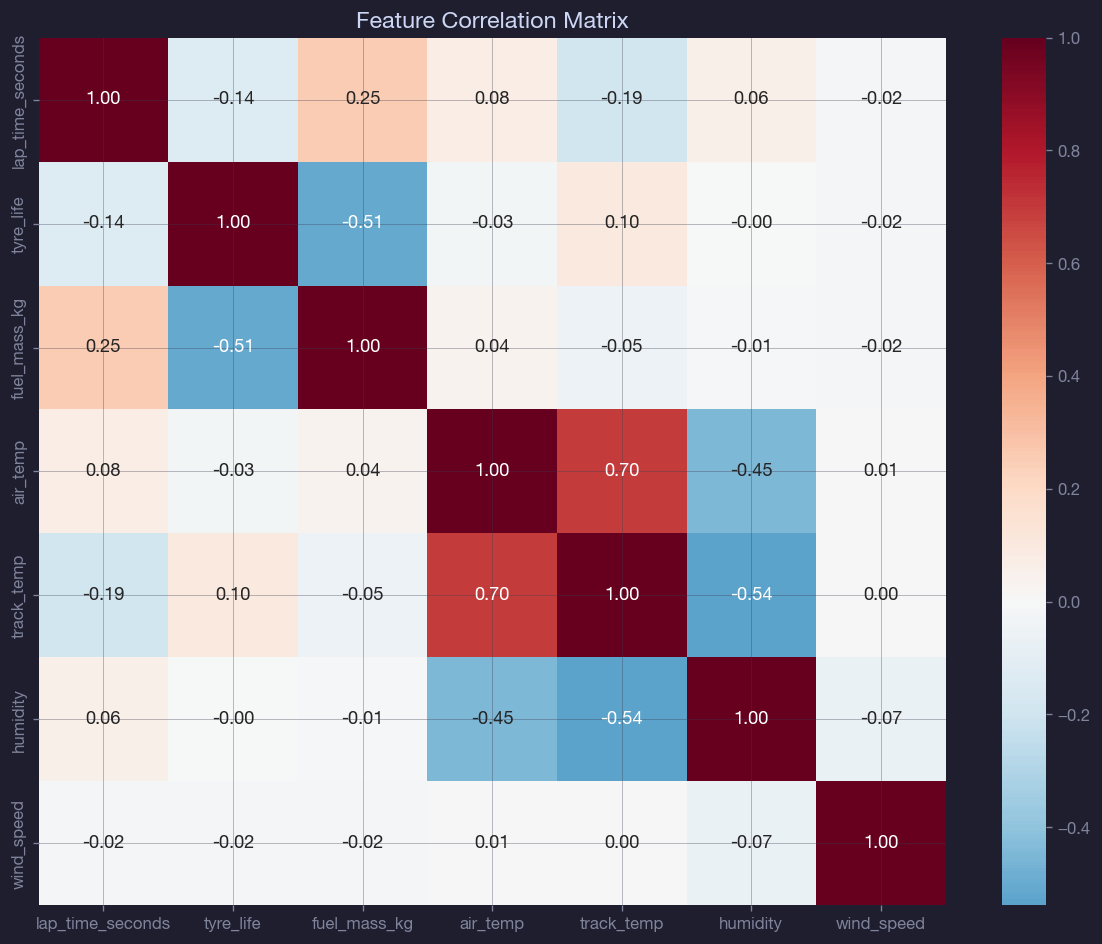

In [6]:
numeric_cols = [
    "lap_time_seconds",
    "tyre_life",
    "fuel_mass_kg",
    "air_temp",
    "track_temp",
    "humidity",
    "wind_speed",
]
available = [c for c in numeric_cols if c in df.columns]
corr = df[available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Fuel Load vs Lap Time

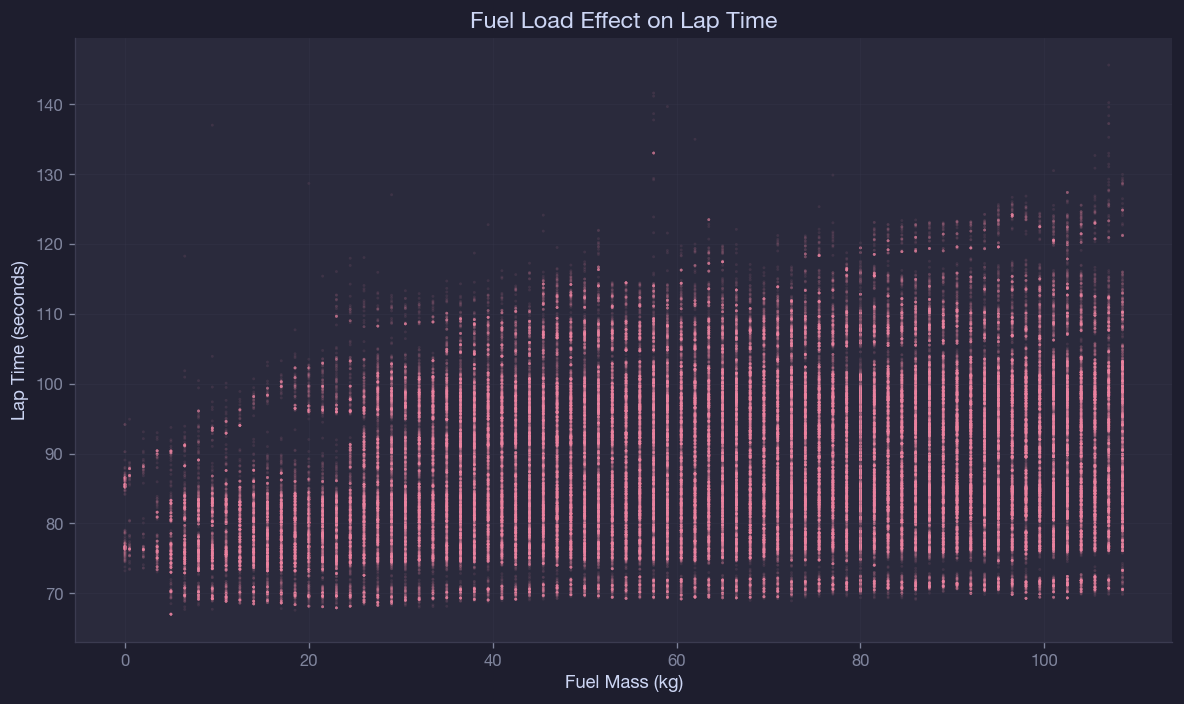

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["fuel_mass_kg"], df["lap_time_seconds"], alpha=0.1, s=3)
ax.set_xlabel("Fuel Mass (kg)")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title("Fuel Load Effect on Lap Time")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Compound-Specific Degradation

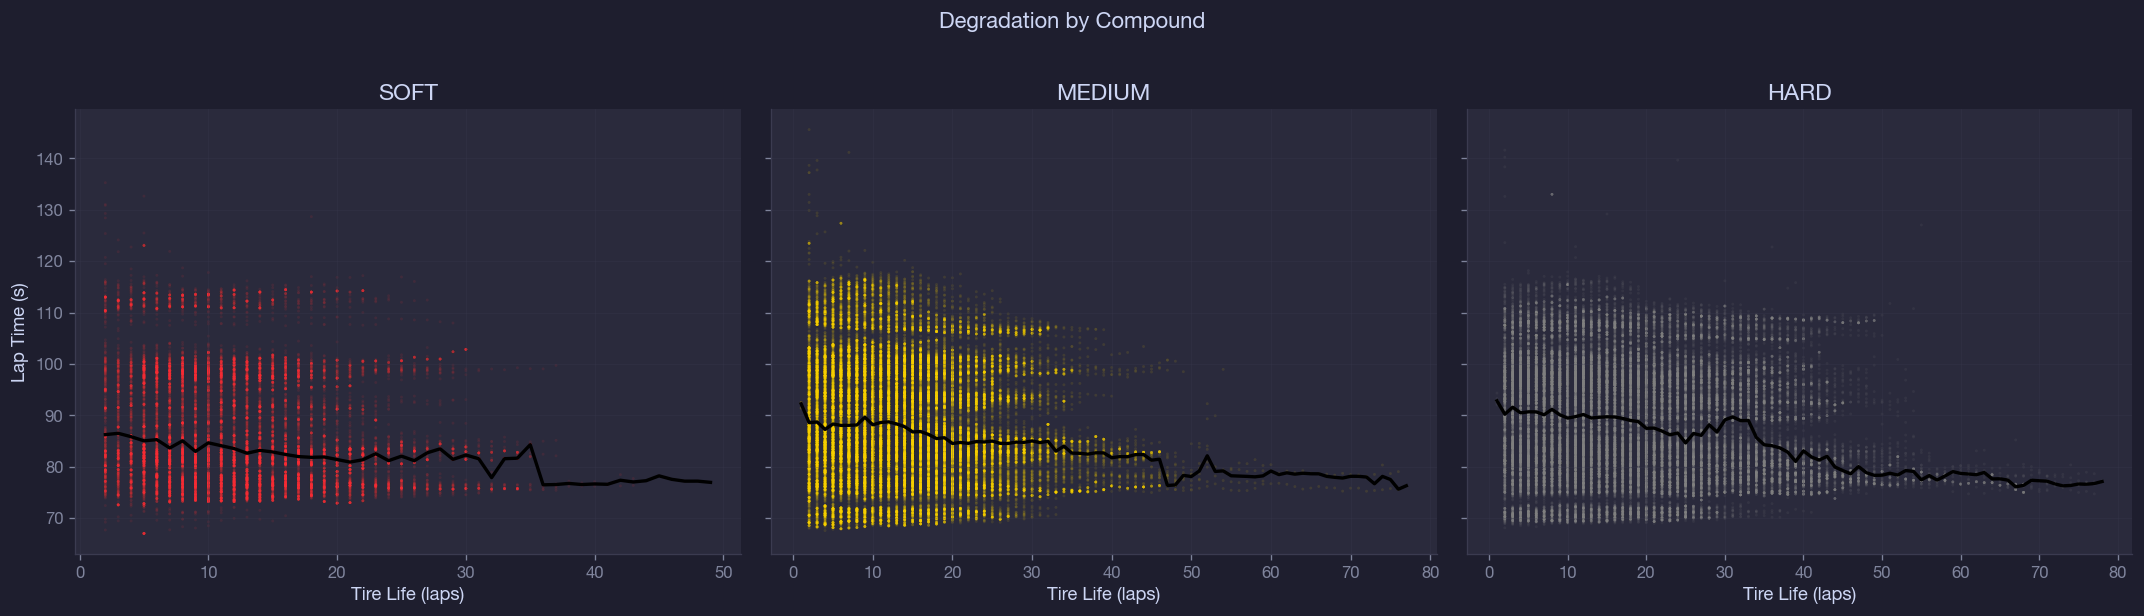

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, compound in zip(axes, ["SOFT", "MEDIUM", "HARD"], strict=False):
    subset = df[df["compound"] == compound]
    color = {"SOFT": "#FF3333", "MEDIUM": "#FFD700", "HARD": "#888888"}[compound]
    ax.scatter(subset["tyre_life"], subset["lap_time_seconds"], alpha=0.1, s=3, c=color)
    # Trend line
    if len(subset) > 10:
        trend = subset.groupby("tyre_life")["lap_time_seconds"].median()
        ax.plot(trend.index, trend.values, "k-", linewidth=2)
    ax.set_xlabel("Tire Life (laps)")
    ax.set_ylabel("Lap Time (s)" if compound == "SOFT" else "")
    ax.set_title(f"{compound}")
    ax.grid(True, alpha=0.3)
plt.suptitle("Degradation by Compound", y=1.02)
plt.tight_layout()
plt.show()

## Per-Circuit Comparison

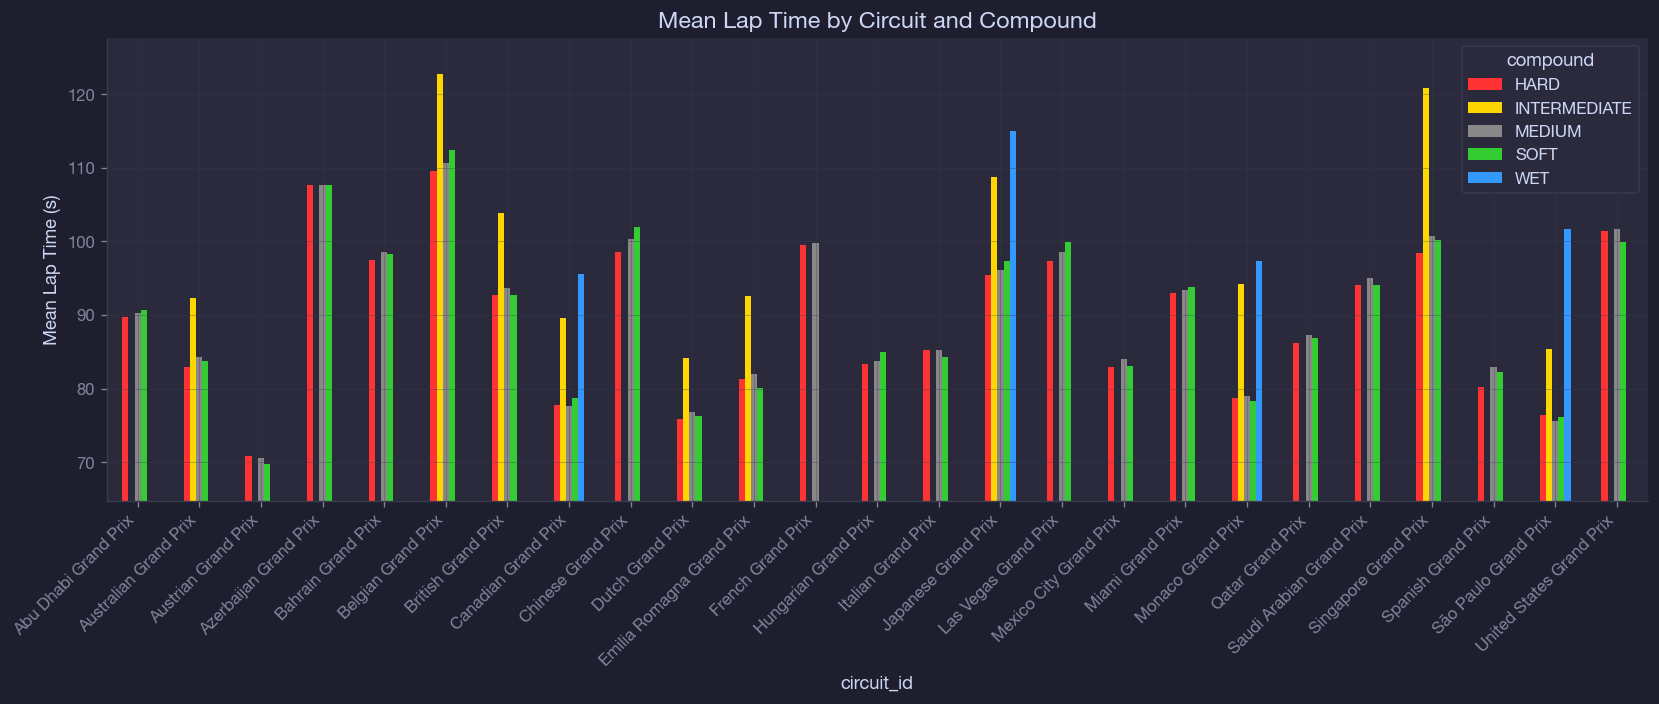

In [10]:
pivot = df.groupby(["circuit_id", "compound"])["lap_time_seconds"].mean().unstack()
fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(
    kind="bar",
    ax=ax,
    color=["#FF3333", "#FFD700", "#888888", "#33CC33", "#3399FF"][: len(pivot.columns)],
)
ax.set_ylabel("Mean Lap Time (s)")
ax.set_title("Mean Lap Time by Circuit and Compound")

# Zoom y-axis to ±5s around the data range
y_min = pivot.min().min()
y_max = pivot.max().max()
ax.set_ylim(y_min - 5, y_max + 5)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()